# GA vs COMPOSITE 비교 (Boxplot)

세 가지 방법의 **Makespan** / **Average Qtime Violation** / **작동 중 고장 횟수(in-process breakdown)** 분포를 Boxplot 으로 비교한다.

| Method | 내용 |
|---|---|
| `GA` | GA 로 탐색한 COMPOSITE 가중치 결과 (`ga_result.xlsx`, 기존 파일) |
| `Composite_threshold` | COMPOSITE rule + `PM_RULE=THRESHOLD`, `PM_HAZARD_THRESHOLD=0.5` |
| `Composite_age` | COMPOSITE rule + `PM_RULE=AGE_REPLACEMENT` |

- `Composite_threshold` / `Composite_age` 결과는 이 노트북에서 직접 시뮬레이션을 돌려 `composite_threshold_result.xlsx` / `composite_age_result.xlsx` 로 저장한다 (GA 와 동일한 컬럼: `best_makespan`/`best_qtime`/`best_fitness`/`failed_count`).
- `failed_count` = 작동 중(setup/working) 고장으로 재투입된 횟수. GA 파일과 동일한 정의로 COMPOSITE 도 계산한다.
- `ga_result.xlsx` 는 한셀(Hancell)로 저장돼 openpyxl 스타일 파서를 통과하지 못하므로, 스타일을 무시하고 시트 XML 을 직접 파싱하는 로더를 사용한다.

In [5]:
import zipfile, re
import logging
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트: 선호 순서대로 두되 '실제 설치된' 것만 적용 → 미설치 폰트 findfont 경고 방지
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
_installed_fonts = {f.name for f in fm.fontManager.ttflist}
plt.rcParams['font.family'] = [f for f in ['Noto Sans KR', 'Malgun Gothic'] if f in _installed_fonts] + ['sans-serif']
plt.rcParams['axes.unicode_minus'] = False

_NS = '{http://schemas.openxmlformats.org/spreadsheetml/2006/main}'


def read_xlsx_raw(path, sheet='xl/worksheets/sheet1.xml'):
    """스타일 정보를 무시하고 시트 XML 을 직접 읽어 DataFrame 으로 반환.

    pandas/openpyxl 이 한셀 저장본의 stylesheet 에서 TypeError 를 내는 문제를 우회한다.
    """
    z = zipfile.ZipFile(path)
    ns = {'x': _NS[1:-1]}

    # 공유 문자열 테이블
    shared = []
    if 'xl/sharedStrings.xml' in z.namelist():
        root = ET.fromstring(z.read('xl/sharedStrings.xml'))
        for si in root.findall('x:si', ns):
            shared.append(''.join(t.text or '' for t in si.iter(f'{_NS}t')))

    root = ET.fromstring(z.read(sheet))
    rows = []
    for row in root.iter(f'{_NS}row'):
        cells = {}
        for c in row.findall('x:c', ns):
            col = re.match(r'[A-Z]+', c.get('r')).group()
            v = c.find('x:v', ns)
            val = v.text if v is not None else None
            if c.get('t') == 's' and val is not None:
                val = shared[int(val)]
            cells[col] = val
        rows.append(cells)

    cols = sorted({k for r in rows for k in r})
    data = [[r.get(c) for c in cols] for r in rows]
    df = pd.DataFrame(data, columns=cols)
    df.columns = df.iloc[0]            # 첫 행을 헤더로
    df = df[1:].reset_index(drop=True)
    return df.apply(pd.to_numeric, errors='coerce')


def load_result(path):
    """pandas 로 먼저 시도하고, 실패하면 raw 로더로 폴백."""
    try:
        return pd.read_excel(path)
    except Exception:
        return read_xlsx_raw(path)

## Composite_threshold / Composite_age 시뮬레이션 실행 및 저장

`COMPOSITE` rule 을 `PM_RULE=THRESHOLD(0.5)` / `PM_RULE=AGE_REPLACEMENT` 두 가지로 각각 `N_RUNS`회 실행해
GA 결과와 동일한 컬럼(`best_makespan`/`best_qtime`/`best_fitness`)에 **`failed_count`(작동 중 고장 횟수)** 를 추가해 저장한다.

In [6]:
# ── Composite_threshold / Composite_age 결과 생성 (시뮬레이션 직접 실행) ──────
# GA 파일(ga_result.xlsx)과 동일한 컬럼·단위로 저장하되, failed_count(작동 중 고장 횟수)를 포함.
import os, json, random, time
import simpy
from dotenv import load_dotenv
from utils import DataLoader, EventLogger
from simulation import Scheduler
from simulation.priority import set_transition_risk_table

load_dotenv(override=True)
BASE_DATA_PATH = os.getenv('BASE_DATA_PATH', 'data')

# 내부 계산 단위 분(M), 고장 on, PM on 으로 고정
os.environ['TIME_UNIT'] = 'M'
os.environ['DOWN_ACTIVE'] = 'True'
os.environ['PM_ACTIVE'] = 'True'

data_loader = DataLoader(BASE_DATA_PATH)
data = data_loader.load_all_data()
N_JOBS = int(len(data['jobs']))

# transition 위험 테이블 (없으면 γ 항 무효)
_risk_cache = os.path.join('tuning', 'transition_risk.json')
if os.path.exists(_risk_cache):
    with open(_risk_cache, 'r', encoding='utf-8') as f:
        set_transition_risk_table(json.load(f))

# COMPOSITE 6항 고정 계수 (.env COMPOSITE_W_*)
COMPOSITE_TERMS_FIXED = ['PT', 'SLACK', 'SETUP', 'C_TRANSITION', 'COMPLETION_FAST', 'WAITING']
W_COMPOSITE = [float(os.getenv(f'COMPOSITE_W_{t}', '0.0')) for t in COMPOSITE_TERMS_FIXED]

# GA fitness 와 동일한 정규화 상수 (tuning/full6_pso_result.json)
with open(os.path.join('tuning', 'full6_pso_result.json'), 'r', encoding='utf-8') as f:
    _pso_cfg = json.load(f)['config']
MK_REF     = float(_pso_cfg['mk_ref'])       # 분 단위 makespan 기준
QV_REF_AQT = float(_pso_cfg['qv_ref_aqt'])   # 분/job 단위 AQT 기준
W1, W2 = 1.0, 1.0

N_RUNS = 30
BASE_SEED = 0

# AGE_REPLACEMENT 처럼 threshold 가 불필요한 rule 에 넘길 기본값 (Scheduler 시그니처용, 내부 무시됨)
DEFAULT_THRESHOLD = 0.5


def count_inproc_breakdowns(log_df):
    """작동 중(setup/working) 고장으로 재투입된 횟수 (= failed_count).

    breakdown 으로 run() 이 interrupt 되면 같은 op 로 WAITING 에 재진입한다.
    job 별 WAITING 이벤트의 op_id 가 직전과 동일하게 연속된 case 수.
    """
    jl = log_df[(log_df['resource'] == 'job') &
                (log_df['event'].str.startswith('waiting'))].sort_values(['id', 'start'])
    same = (jl['id'] == jl['id'].shift()) & (jl['op_id'] == jl['op_id'].shift())
    return int(same.sum())


def run_composite_pm(pm_rule, seed, threshold=None):
    """COMPOSITE + 주어진 PM_RULE 1회 실행 → (makespan_min, qtime_total_min, failed_count).

    threshold 는 THRESHOLD rule 전용. AGE_REPLACEMENT/MTTF 는 무시되므로 None 이면 기본값 사용.
    """
    os.environ['JOB_RULE'] = 'COMPOSITE'
    os.environ['PM_RULE'] = pm_rule
    os.environ['COMPOSITE_TERMS'] = ','.join(COMPOSITE_TERMS_FIXED)
    os.environ['COMPOSITE_WEIGHTS'] = ','.join(str(float(w)) for w in W_COMPOSITE)

    random.seed(seed)
    env = simpy.Environment()
    logger = EventLogger(env)
    scheduler = Scheduler(
        env=env, data=data, event_logger=logger,
        pm_hazard_threshold=DEFAULT_THRESHOLD if threshold is None else threshold,
    )
    env.run(until=scheduler.job_chk_process)
    log_df = pd.DataFrame(logger.logs)

    job_log = log_df[log_df['resource'] == 'job']
    makespan = float(job_log.groupby('id')['finish'].max().max())          # 분
    qv = log_df[log_df['event'] == 'qtime_over']
    qtime_total = float((qv['finish'] - qv['start']).sum()) if len(qv) > 0 else 0.0  # 분
    failed = count_inproc_breakdowns(log_df)
    return makespan, qtime_total, failed


def run_and_save(pm_rule, out_path, threshold=None):
    """N_RUNS 회 실행해 GA 와 동일 컬럼(best_makespan/best_qtime/best_fitness/failed_count)으로 저장.

    threshold 미지정(None) 이면 THRESHOLD 이외 rule(AGE_REPLACEMENT 등)로 간주해 기본값으로 실행.
    """
    rows = []
    t0 = time.time()
    for i in range(N_RUNS):
        mk, qv, fc = run_composite_pm(pm_rule, BASE_SEED + i, threshold=threshold)
        aqt = qv / N_JOBS
        rows.append({
            'best_makespan': mk / 60.0,                                 # 분 → 시간
            'best_qtime':    aqt / 60.0,                                # 분/job → 시간 (AQT)
            'best_fitness':  W1 * (mk / MK_REF) + W2 * (aqt / QV_REF_AQT),
            'failed_count':  fc,                                        # 작동 중 고장 횟수
        })
    df = pd.DataFrame(rows)
    df.to_excel(out_path, index=False)
    _thr_label = 'n/a' if threshold is None else threshold
    print(f"  [{pm_rule:16s} thr={_thr_label}] {N_RUNS}회, {time.time()-t0:.1f}s → {out_path}")
    return df


print(f"N_JOBS={N_JOBS}, MK_REF={MK_REF:.1f}(분), QV_REF_AQT={QV_REF_AQT:.1f}(분/job)")
print(f"COMPOSITE 6항 계수: {dict(zip(COMPOSITE_TERMS_FIXED, W_COMPOSITE))}\n")

_t = time.time()
# THRESHOLD: threshold=0.5 사용 / AGE_REPLACEMENT: threshold 불필요 → 생략
comp_thr = run_and_save('THRESHOLD', 'composite_threshold_result.xlsx', threshold=0.5)
comp_age = run_and_save('AGE_REPLACEMENT', 'composite_age_result.xlsx')

os.environ['PM_ACTIVE'] = 'False'   # 환경 원복
print(f"\n총 {time.time()-_t:.1f}s, 두 파일 저장 완료.")

N_JOBS=60, MK_REF=14734.2(분), QV_REF_AQT=1140.0(분/job)
COMPOSITE 6항 계수: {'PT': 0.0, 'SLACK': 0.4323, 'SETUP': 0.4078, 'C_TRANSITION': 0.0646, 'COMPLETION_FAST': 0.0435, 'WAITING': 0.0519}

  [THRESHOLD        thr=0.5] 30회, 39.7s → composite_threshold_result.xlsx
  [AGE_REPLACEMENT  thr=n/a] 30회, 38.8s → composite_age_result.xlsx

총 78.5s, 두 파일 저장 완료.


In [7]:
ga       = load_result('ga_result.xlsx')
comp_thr = load_result('composite_threshold_result.xlsx')
comp_age = load_result('composite_age_result.xlsx')

# 비교 대상 3개 method (순서 = boxplot x축 순서)
methods = {
    'GA':                  ga,
    'Composite_threshold': comp_thr,
    'Composite_age':       comp_age,
}
for name, df in methods.items():
    print(f'{name:22s}: {df.shape}')

# best_makespan / best_qtime / failed_count 만 모아 describe
pd.concat(
    {name: df[['best_makespan', 'best_qtime', 'failed_count']].describe()
     for name, df in methods.items()},
    axis=1
)

GA                    : (30, 6)
Composite_threshold   : (30, 4)
Composite_age         : (30, 4)


GA                         Composite_threshold             \
      best_makespan best_qtime failed_count       best_makespan best_qtime   
count     30.000000  30.000000    30.000000           30.000000  30.000000   
mean     220.292446   0.327962     8.100000          210.191371   1.204631   
std        5.671827   0.242805     2.577756            7.035967   0.814938   
min      209.665680   0.047798     3.000000          197.128965   0.092796   
25%      216.670708   0.144307     7.000000          205.742539   0.689484   
50%      219.530323   0.237092     8.000000          210.007601   1.164226   
75%      222.932915   0.459036    10.000000          215.025867   1.555338   
max      233.676833   1.141369    14.000000          227.184694   4.271476   

                   Composite_age                          
      failed_count best_makespan best_qtime failed_count  
count    30.000000     30.000000  30.000000    30.000000  
mean     18.766667    220.560007   1.247990    13.200000  
std       4.485097      7.072874   0.867969     3.661543  
min      11.000000    205.740667   0.000000     7.000000  
25%      15.000000    216.650314   0.690658    11.000000  
50%      19.000000    220.165447   1.232383    13.500000  
75%      22.000000    223.776379   1.593187    15.750000  
max      26.000000    234.909787   3.858595    21.000000

In [8]:
# 요약 통계 비교 (mean ± std)
_metrics = {
    'Makespan (hour)':            'best_makespan',
    'Avg Qtime Violation (hour)': 'best_qtime',
    'In-process Breakdown':       'failed_count',
}
summary = pd.DataFrame({
    f'{name} (mean)': [methods[name][col].mean() for col in _metrics.values()]
    for name in methods
}, index=list(_metrics.keys()))
summary_std = pd.DataFrame({
    f'{name} (std)': [methods[name][col].std() for col in _metrics.values()]
    for name in methods
}, index=list(_metrics.keys()))
summary.join(summary_std).round(3)

,GA (mean),Composite_threshold (mean),Composite_age (mean),GA (std),Composite_threshold (std),Composite_age (std)
Makespan (hour),220.292,210.191,220.560,5.672,7.036,7.073
Avg Qtime Violation (hour),0.328,1.205,1.248,0.243,0.815,0.868
In-process Breakdown,8.100,18.767,13.200,2.578,4.485,3.662


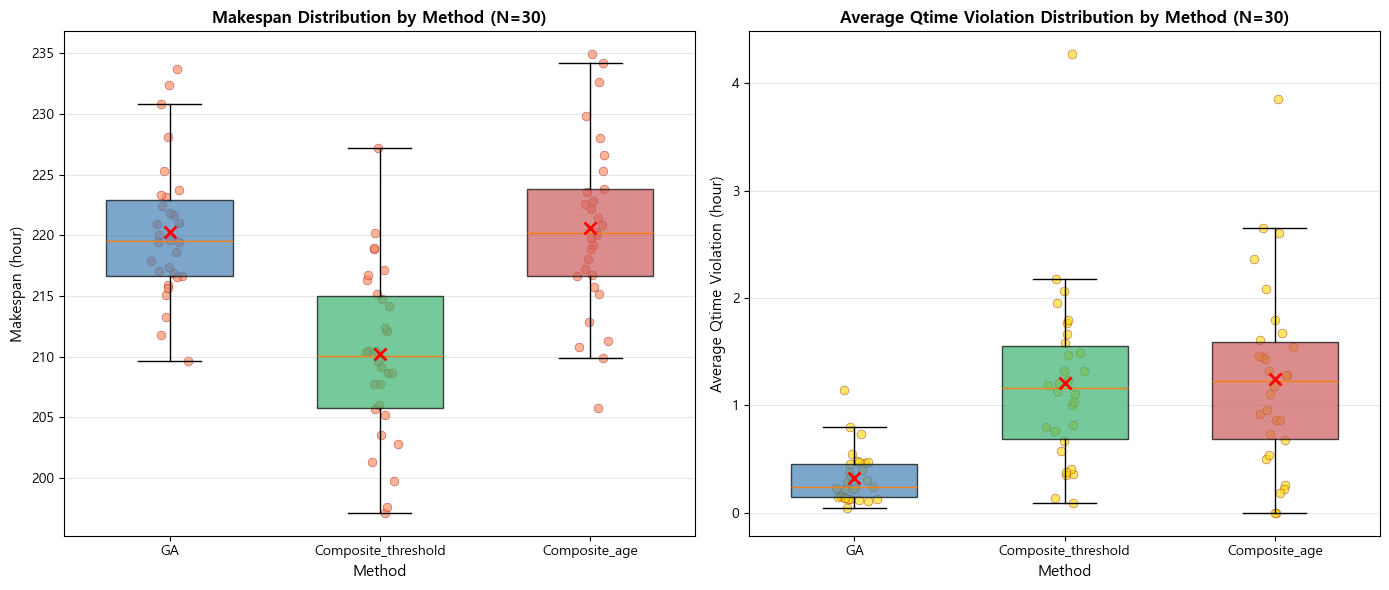

In [9]:
method_labels = list(methods.keys())
METHOD_COLORS = ['steelblue', 'mediumseagreen', 'indianred']


def _draw_box(ax, col, ylabel, title, dot_color='coral'):
    """박스 + 지터 산점도 + 빨간 × 평균. method별로 다른 박스 색."""
    box_data = [methods[m][col].dropna().values for m in method_labels]
    bp = ax.boxplot(box_data, tick_labels=method_labels, patch_artist=True,
                    widths=0.6, showfliers=False)
    for patch, color in zip(bp['boxes'], METHOD_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for i, vals in enumerate(box_data):
        x_jit = [i + 1 + np.random.normal(0, 0.04) for _ in vals]
        ax.scatter(x_jit, vals, alpha=0.6, s=40, color=dot_color,
                   edgecolors='darkred', linewidth=0.4)
        ax.plot(i + 1, np.mean(vals), marker='x', markersize=8,
                markeredgewidth=2, color='red', zorder=5)
    ax.set_xlabel('Method', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
_draw_box(axes[0], 'best_makespan', 'Makespan (hour)',
          f'Makespan Distribution by Method (N={len(ga)})')
_draw_box(axes[1], 'best_qtime', 'Average Qtime Violation (hour)',
          f'Average Qtime Violation Distribution by Method (N={len(ga)})',
          dot_color='gold')
plt.tight_layout()
plt.savefig('GA_Composite_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 작동 중 고장 횟수 (failed_count) 비교

세 method 의 `failed_count`(작동 중 고장으로 재투입된 횟수) 분포를 별도 boxplot 으로 비교한다.

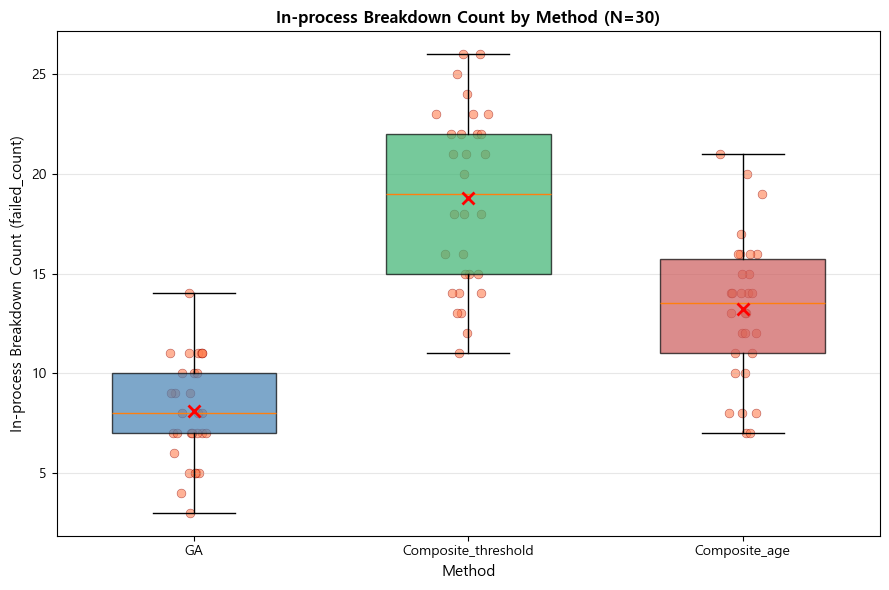

In [11]:
# ── In-process Breakdown Count (failed_count) — 별도 boxplot ─────────────────
# 위 그래프와 동일 색: GA=blue, Composite_threshold=green, Composite_age=red
fig, ax = plt.subplots(figsize=(9, 6))
box_data = [methods[m]['failed_count'].dropna().values for m in method_labels]
bp = ax.boxplot(box_data, tick_labels=method_labels, patch_artist=True,
                widths=0.6, showfliers=False)
for patch, color in zip(bp['boxes'], METHOD_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, vals in enumerate(box_data):
    x_jit = [i + 1 + np.random.normal(0, 0.04) for _ in vals]
    ax.scatter(x_jit, vals, alpha=0.6, s=40, color='coral',
               edgecolors='darkred', linewidth=0.4)
    ax.plot(i + 1, np.mean(vals), marker='x', markersize=8,
            markeredgewidth=2, color='red', zorder=5)

ax.set_xlabel('Method', fontsize=11)
ax.set_ylabel('In-process Breakdown Count (failed_count)', fontsize=11)
ax.set_title(f'In-process Breakdown Count by Method (N={len(ga)})',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('GA_Composite_failed_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── 목적함수 값(J = best_fitness) 비교 ───────────────────────────────────────
# J = w1·Mk/mk_ref + w2·AQT/qv_ref_aqt  (w1=w2=1) — 세 method 모두 동일 정규화 상수 사용.
obj_summary = pd.DataFrame({
    'mean':   [methods[m]['best_fitness'].mean()   for m in method_labels],
    'std':    [methods[m]['best_fitness'].std()    for m in method_labels],
    'min':    [methods[m]['best_fitness'].min()    for m in method_labels],
    'median': [methods[m]['best_fitness'].median() for m in method_labels],
    'max':    [methods[m]['best_fitness'].max()    for m in method_labels],
}, index=method_labels).round(4)

print(f"=== Objective Value J (best_fitness, N={len(ga)}) ===")
print(obj_summary.to_string())
_best = obj_summary['mean'].idxmin()   # J 는 작을수록 우수
print(f"\n평균 J 최소(최우수): {_best}  (J̄ = {obj_summary.loc[_best, 'mean']:.4f})")
obj_summary

=== Objective Value J (best_fitness, N=30) ===
                       mean     std     min  median     max
GA                   0.9143  0.0292  0.8603  0.9110  0.9998
Composite_threshold  0.9193  0.0597  0.8423  0.9160  1.1092
Composite_age        0.9638  0.0699  0.8495  0.9539  1.1568

평균 J 최소(최우수): GA  (J̄ = 0.9143)


,mean,std,min,median,max
GA,0.9143,0.0292,0.8603,0.9110,0.9998
Composite_threshold,0.9193,0.0597,0.8423,0.9160,1.1092
Composite_age,0.9638,0.0699,0.8495,0.9539,1.1568
